In [49]:
import pandas as pd

df = pd.read_csv('../Data/flight_delays.csv')
df.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


In [50]:
#Criar a Coluna atraso
df['delay'] = (df['DelayMinutes'] > 15).astype(int)

In [51]:
df[['DelayMinutes','delay']].head()

,DelayMinutes,delay
0,8,0
1,2,0
2,14,0
3,-10,0
4,24,1


In [52]:
#Preparar Features Básicsa
df['ScheduledDeparture'] = pd.to_datetime(df['ScheduledDeparture'])
df['hour'] = df['ScheduledDeparture'].dt.hour
df['day'] = df['ScheduledDeparture'].dt.day
df['is_weekend'] = df['ScheduledDeparture'].dt.dayofweek >= 5
df['is_weekend'] = df['is_weekend'].astype(int)
df['month'] = df['ScheduledDeparture'].dt.month

In [53]:
df.columns

Index(['FlightID', 'Airline', 'FlightNumber', 'Origin', 'Destination',
       'ScheduledDeparture', 'ActualDeparture', 'ScheduledArrival',
       'ActualArrival', 'DelayMinutes', 'DelayReason', 'Cancelled', 'Diverted',
       'AircraftType', 'TailNumber', 'Distance', 'delay', 'hour', 'day',
       'is_weekend', 'month'],
      dtype='str')

In [54]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 21 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             str           
 2   FlightNumber        int64         
 3   Origin              str           
 4   Destination         str           
 5   ScheduledDeparture  datetime64[us]
 6   ActualDeparture     str           
 7   ScheduledArrival    str           
 8   ActualArrival       str           
 9   DelayMinutes        int64         
 10  DelayReason         str           
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        str           
 14  TailNumber          str           
 15  Distance            int64         
 16  delay               int64         
 17  hour                int32         
 18  day                 int32         
 19  is_weekend          int64         
 20  month        

In [55]:
df = df.drop(columns=[
    'DelayReason',
    'ActualDeparture',
    'ActualArrival',
    'ScheduledArrival'
])



A variável DelayReason foi removida devido à alta quantidade de valores ausentes e risco de vazamento de informação.  As variáveis ActualDeparture, ActualArrival e ScheduledArrival foram removidas para evitar vazamento de dados, garantindo que o modelo utilize apenas informações disponíveis antes da ocorrência do voo.

In [56]:
#Diminuir Dataset usar 100k
df = df.sample(n=100000, random_state=42)

In [57]:
#Ver balanceamento
df['delay'].value_counts()

delay
0    63531
1    36469
Name: count, dtype: int64

A variável alvo apresentou distribuição levemente desbalanceada (63% vs 37%), porém dentro de um intervalo aceitável, não sendo necessário aplicar técnicas de balanceamento

In [65]:
#ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# features
features = [
    'Airline', 'Origin', 'Destination',
    'hour', 'day', 'month',
    'Distance', 'is_weekend'
]

X = df[features]
y = df['delay']

# transformar categóricos
X = pd.get_dummies(X, drop_first=True)

# dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# criar modelo
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

# TREINAR (isso estava faltando ou não foi rodado)
model.fit(X_train, y_train)

# prever
y_pred = model.predict(X_test)

#Salvar modelo
import joblib
joblib.dump(model, 'modelo_atraso_voos.pkl')

# avaliação
print("Acurácia:", round(accuracy_score(y_test, y_pred), 4))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Acurácia: 0.5351
              precision    recall  f1-score   support

           0       0.64      0.62      0.63     12706
           1       0.37      0.38      0.38      7294

    accuracy                           0.54     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.54      0.54      0.54     20000



Inicialmente o modelo apresentou viés para a classe majoritária. Após aplicação de balanceamento por ponderação de classes, houve redução na acurácia, porém houve melhora significativa na capacidade de identificar voos atrasados, o que é mais relevante para o problema de negócio.
Foram realizados ajustes de hiperparâmetros, mais arvores e mais profundidade aumentando a complexidade do modelo , visando melhorar a detecção de voos atrasados.

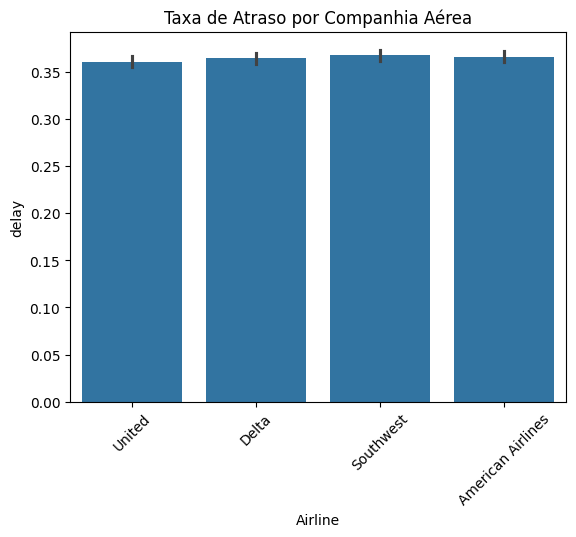

In [66]:
#Atrasos POr Companhia
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.barplot(x='Airline', y='delay', data=df)
plt.title('Taxa de Atraso por Companhia Aérea')
plt.xticks(rotation=45)
plt.show()

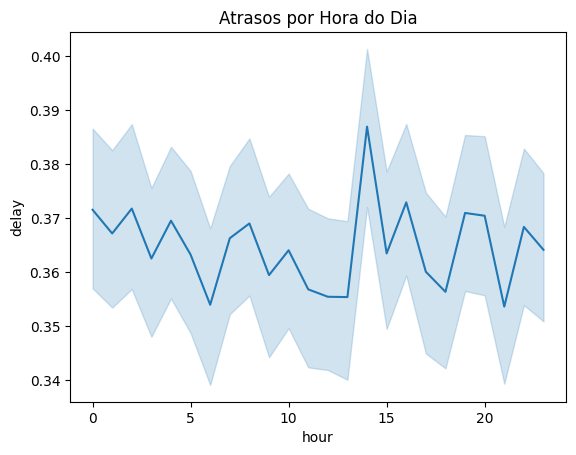

In [67]:
#Atrasos Por Horário
plt.figure()
sns.lineplot(x='hour', y='delay', data=df)
plt.title('Atrasos por Hora do Dia')
plt.show()

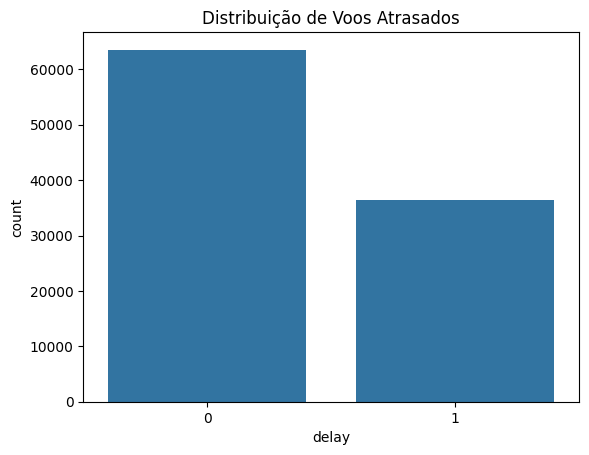

In [68]:
#Distribuição de Atrasos  - Mostra Balanceamento
plt.figure()
sns.countplot(x='delay', data=df)
plt.title('Distribuição de Voos Atrasados')
plt.show()

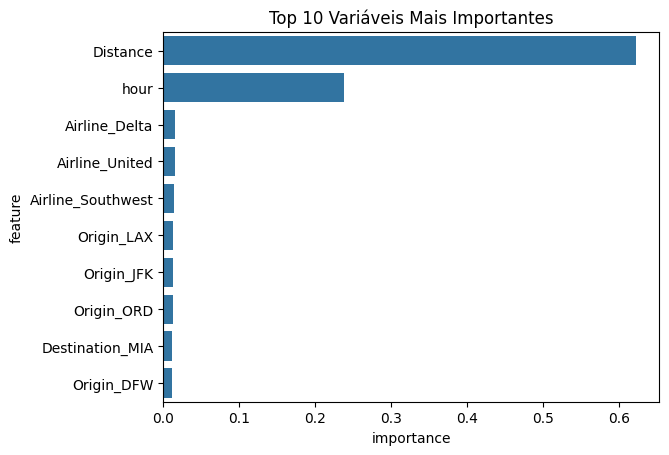

In [69]:
#Importancia das variaveis
import pandas as pd

importances = model.feature_importances_
features_names = X.columns

feat_imp = pd.DataFrame({
    'feature': features_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(10)

plt.figure()
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title('Top 10 Variáveis Mais Importantes')
plt.show()